# Task 1: Diagnostic Enhancement of Chest X-Rays
**Medical Imaging Portfolio** | Author: **23k0069**

### Scenario
Raw single-channel pulmonary X-rays frequently suffer from severe underexposure, masking structural details of the lung cavities and potential fluid accumulation.
This pipeline applies rigorous mathematical transformations to restore dynamic contrast, apply false-color diagnostic mapping, neutralize color cast, threshold dense tissue, and apply logarithmic/gamma transformations.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'gray'
print('Environment and libraries initialized.')

Environment and libraries initialized.


## 1. Load and Display Raw Grayscale Image
Load the underexposed single-channel X-ray matrix from `data/sample_xray.png`.

Dimensions: (512, 512) | Intensity Min: 0, Max: 115


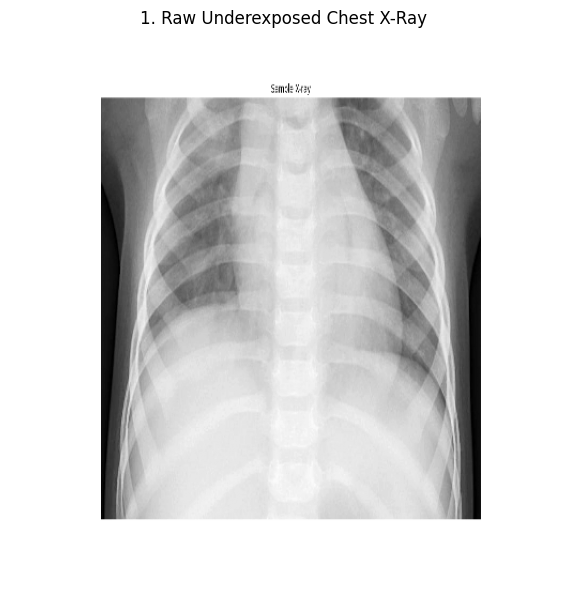

In [2]:
raw = cv2.imread('data/sample_xray.png', cv2.IMREAD_GRAYSCALE)
print(f'Dimensions: {raw.shape} | Intensity Min: {raw.min()}, Max: {raw.max()}')

plt.figure(figsize=(6, 6))
plt.imshow(raw, cmap='gray')
plt.title('1. Raw Underexposed Chest X-Ray')
plt.axis('off')
plt.tight_layout()
plt.savefig('output/01_raw_xray.png', bbox_inches='tight')
plt.show()

## 2. Contrast Enhancement (Histogram Equalization)
Forcefully redistribute the intensity distribution across the dynamic range [0, 255] using cumulative distribution linearization.

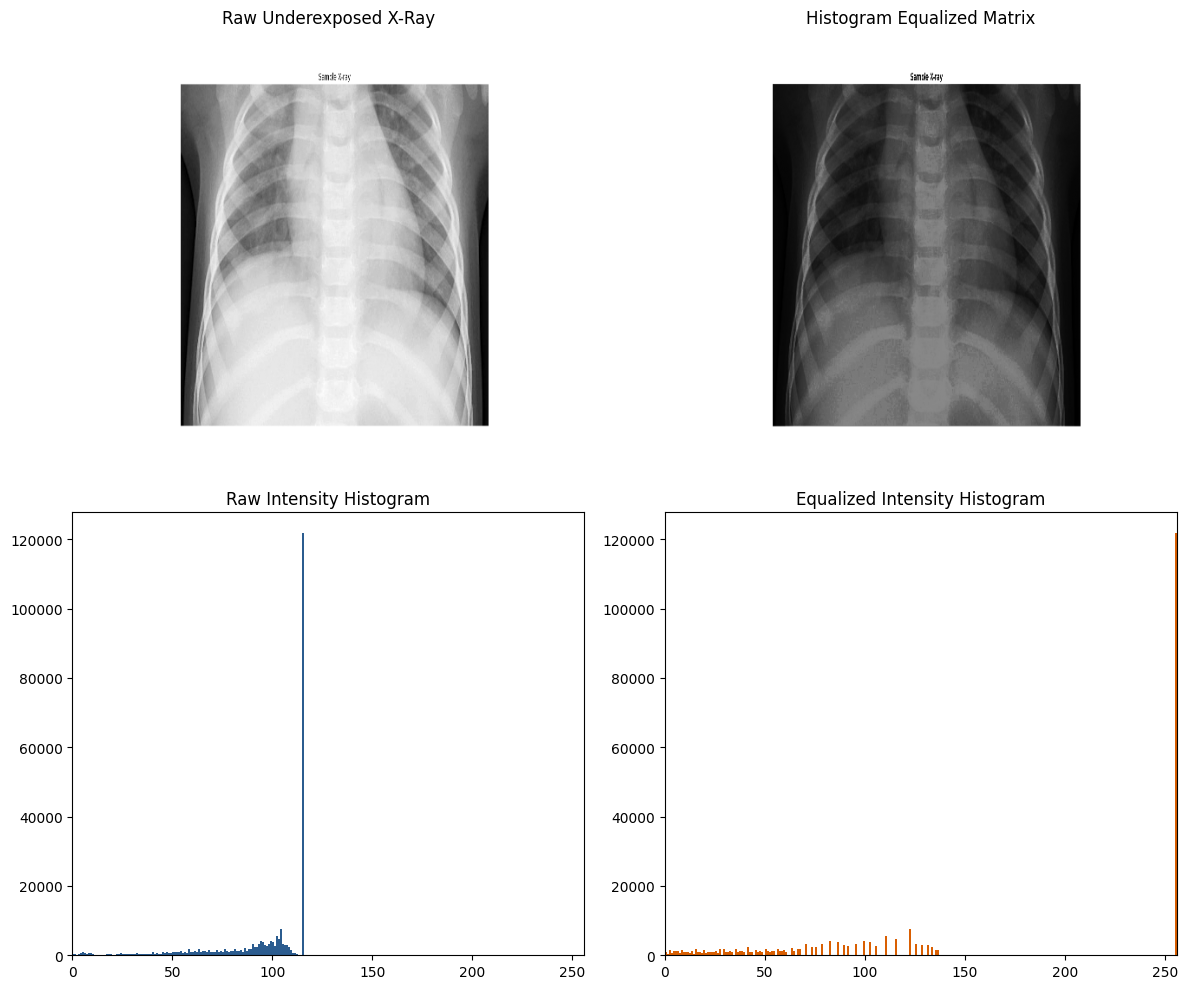

In [3]:
eq = cv2.equalizeHist(raw)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(raw, cmap='gray')
axes[0, 0].set_title('Raw Underexposed X-Ray')
axes[0, 0].axis('off')

axes[0, 1].imshow(eq, cmap='gray')
axes[0, 1].set_title('Histogram Equalized Matrix')
axes[0, 1].axis('off')

axes[1, 0].hist(raw.ravel(), bins=256, range=[0, 256], color='#2b5c8f')
axes[1, 0].set_title('Raw Intensity Histogram')
axes[1, 0].set_xlim([0, 256])

axes[1, 1].hist(eq.ravel(), bins=256, range=[0, 256], color='#d95f02')
axes[1, 1].set_title('Equalized Intensity Histogram')
axes[1, 1].set_xlim([0, 256])

plt.tight_layout()
plt.savefig('output/02_histogram_equalization.png', bbox_inches='tight')
plt.show()

## 3. False-Color Mapping (COLORMAP_JET)
Convert the equalized grayscale matrix into a pseudocolor heatmap using `COLORMAP_JET` to accentuate fluid-tissue density gradients.

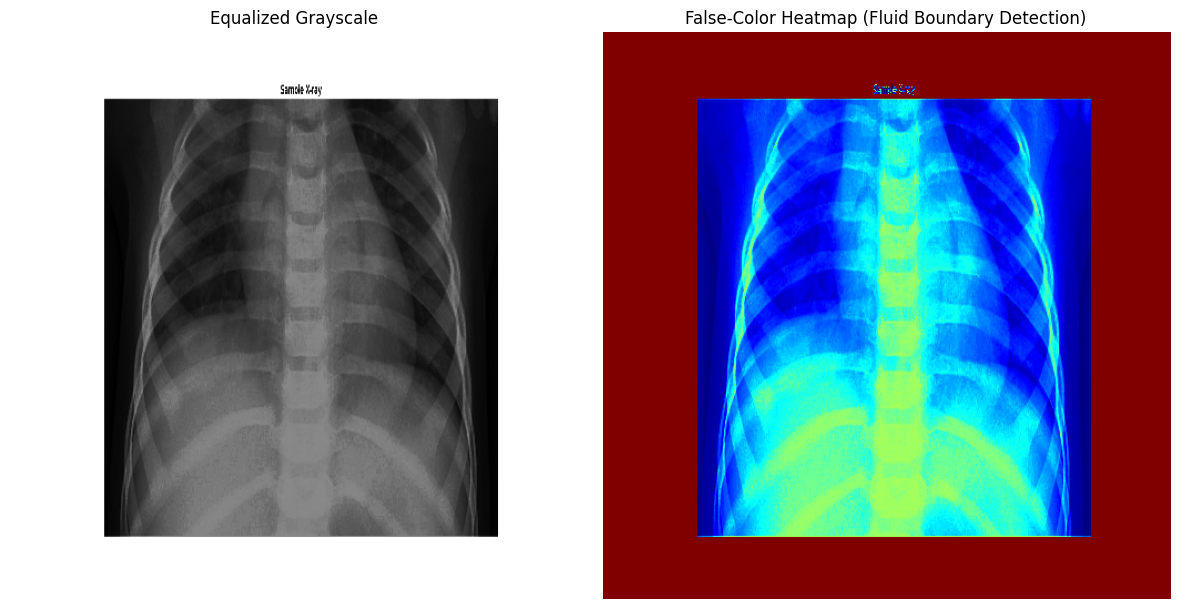

In [4]:
heat = cv2.applyColorMap(eq, cv2.COLORMAP_JET)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(eq, cmap='gray')
axes[0].set_title('Equalized Grayscale')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(heat, cv2.COLOR_BGR2RGB))
axes[1].set_title('False-Color Heatmap (Fluid Boundary Detection)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/03_colormap_jet.png', bbox_inches='tight')
plt.show()

## 4. Color Balance (Lighting Correction)
Simulate lighting correction by applying a Gray-World mathematical color balance shift to neutralize artificial color bias.

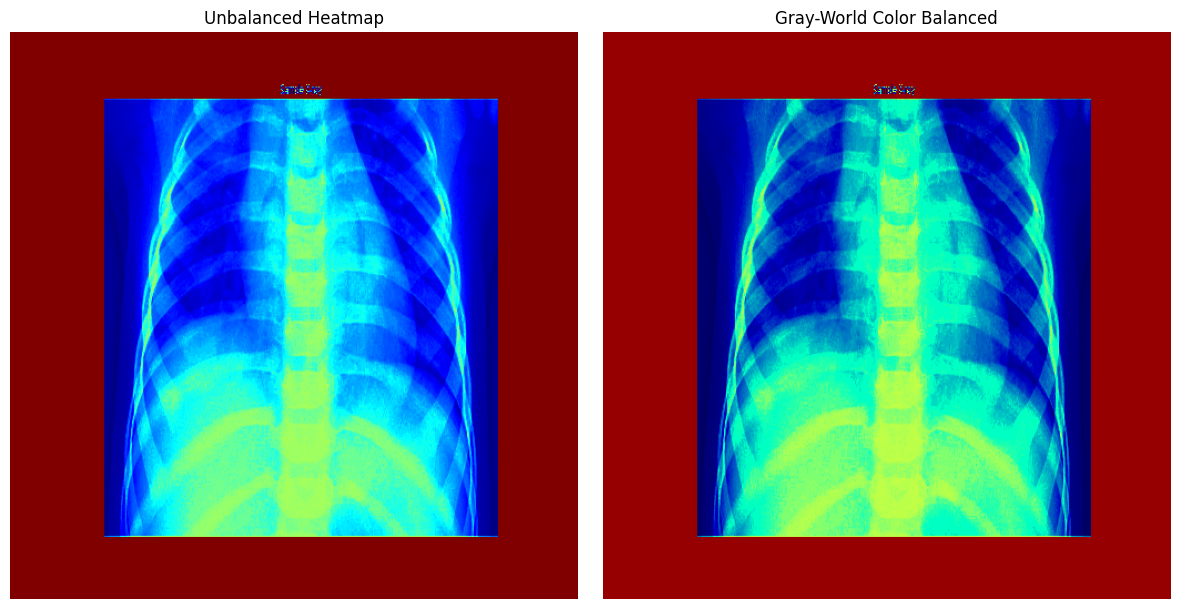

In [5]:
b, g, r = cv2.split(heat)
mb, mg, mr = b.mean(), g.mean(), r.mean()
avg = (mb + mg + mr) / 3.0

b_cb = np.clip(b * (avg / mb), 0, 255).astype(np.uint8)
g_cb = np.clip(g * (avg / mg), 0, 255).astype(np.uint8)
r_cb = np.clip(r * (avg / mr), 0, 255).astype(np.uint8)
cb = cv2.merge([b_cb, g_cb, r_cb])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(heat, cv2.COLOR_BGR2RGB))
axes[0].set_title('Unbalanced Heatmap')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(cb, cv2.COLOR_BGR2RGB))
axes[1].set_title('Gray-World Color Balanced')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/04_color_balance.png', bbox_inches='tight')
plt.show()

## 5. Color Filtering (Dense Tissue Thresholding)
Dense tissues (cortical bone, clavicles, ribs, infiltrates) reflect high intensities. Apply strict mathematical thresholding to segment them.

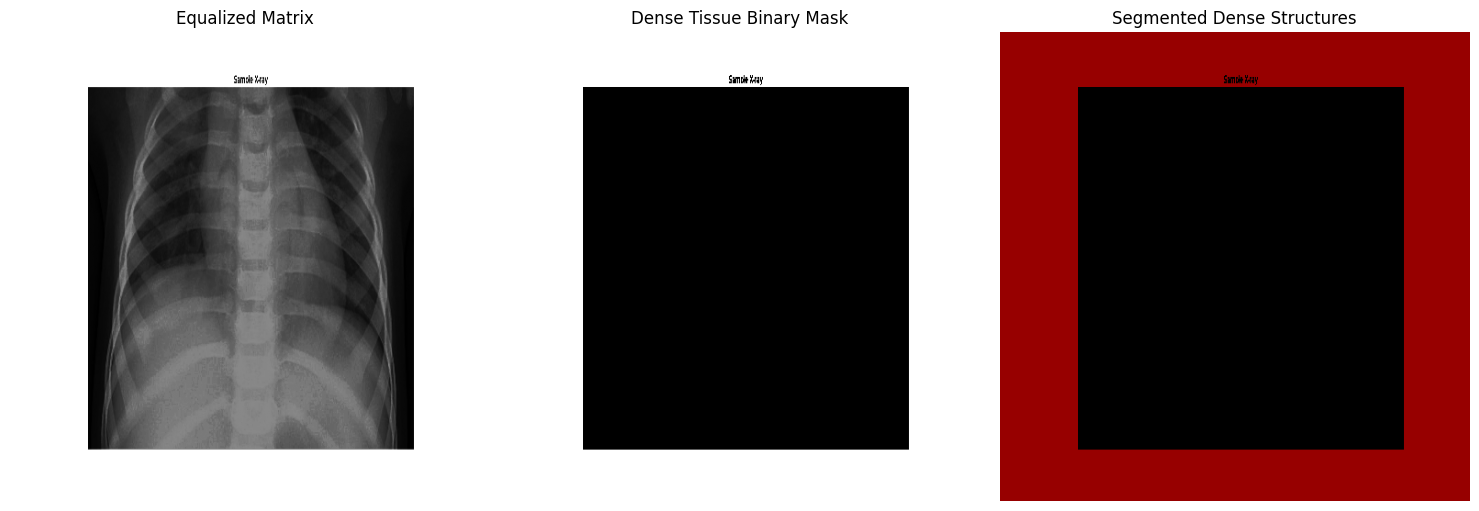

In [6]:
_, mask = cv2.threshold(eq, 180, 255, cv2.THRESH_BINARY)
dense = cv2.bitwise_and(cb, cb, mask=mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(eq, cmap='gray')
axes[0].set_title('Equalized Matrix')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Dense Tissue Binary Mask')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(dense, cv2.COLOR_BGR2RGB))
axes[2].set_title('Segmented Dense Structures')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('output/05_dense_tissue_mask.png', bbox_inches='tight')
plt.show()

## 6. Logarithmic Transformation
Expand compressed low-intensity values using $s = c \cdot \ln(1 + r)$ to unveil peripheral ribcage boundaries.

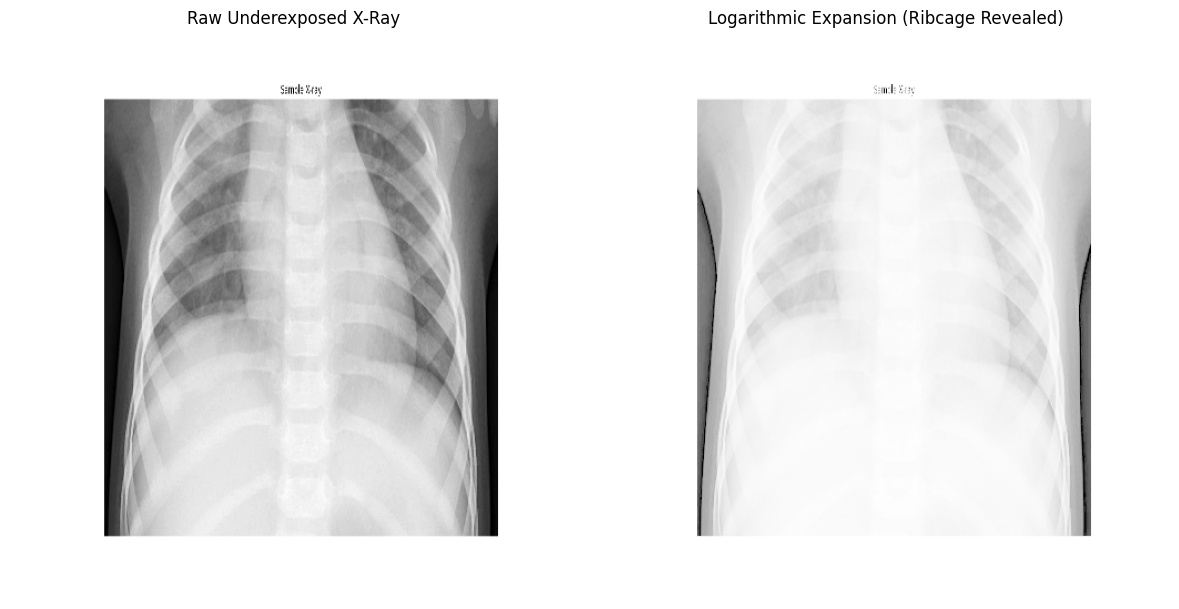

In [7]:
c_log = 255.0 / np.log(1.0 + np.max(raw))
log_img = (c_log * np.log(1.0 + raw.astype(np.float32))).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(raw, cmap='gray')
axes[0].set_title('Raw Underexposed X-Ray')
axes[0].axis('off')

axes[1].imshow(log_img, cmap='gray')
axes[1].set_title('Logarithmic Expansion (Ribcage Revealed)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('output/06_log_transformed.png', bbox_inches='tight')
plt.show()

## 7. Power-Law (Gamma) Transformation
Apply fractional power-law $s = 255 \cdot (r / 255)^\gamma$ with $\gamma < 1.0$ ($\gamma = 0.55$) to lift midtone soft-tissue contrast while preventing bone over-saturation.

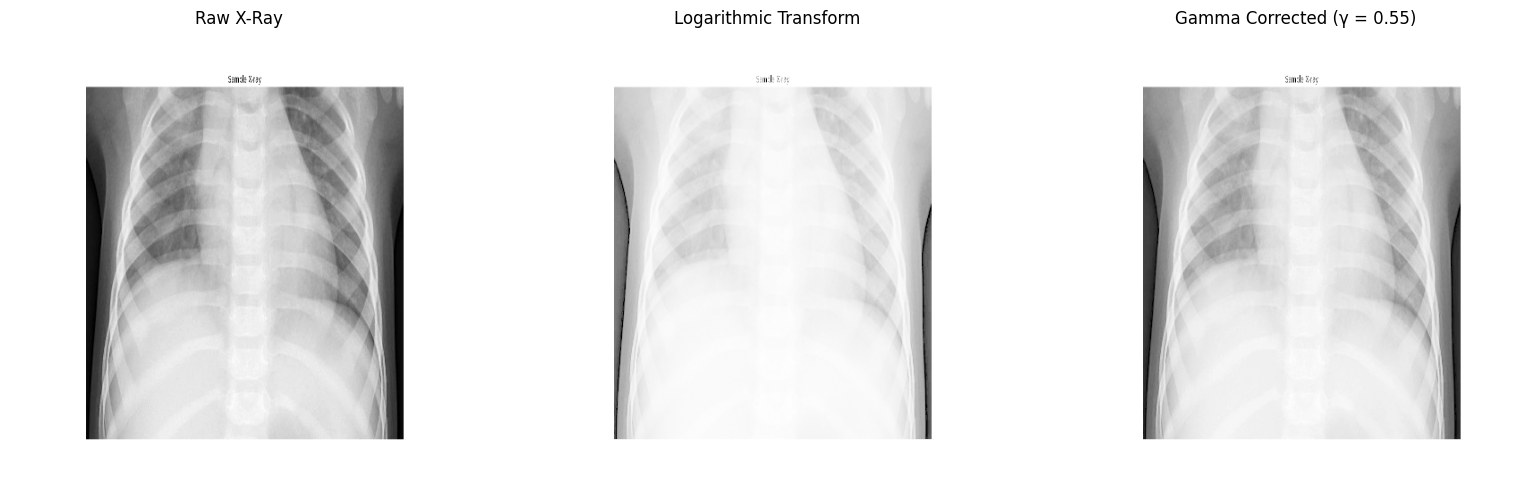

In [8]:
gamma = 0.55
gam_img = np.clip(255.0 * ((raw / 255.0) ** gamma), 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(raw, cmap='gray')
axes[0].set_title('Raw X-Ray')
axes[0].axis('off')

axes[1].imshow(log_img, cmap='gray')
axes[1].set_title('Logarithmic Transform')
axes[1].axis('off')

axes[2].imshow(gam_img, cmap='gray')
axes[2].set_title(f'Gamma Corrected (γ = {gamma})')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('output/07_gamma_transformed.png', bbox_inches='tight')
plt.show()

## 8. Complete Pipeline Diagnostic Overview

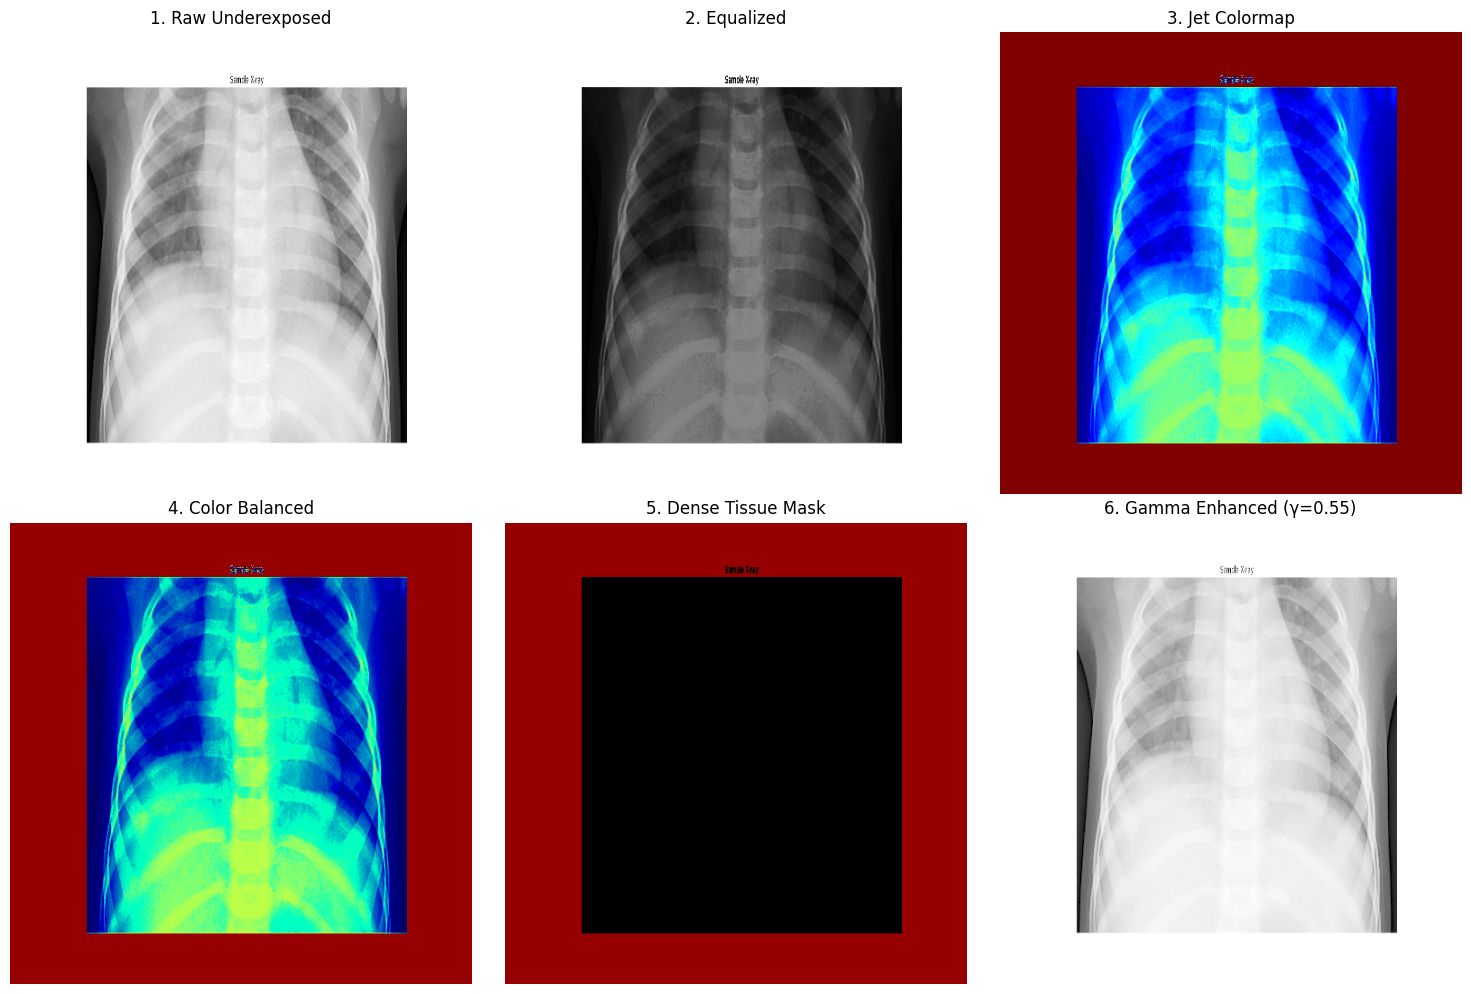

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(raw, cmap='gray')
axes[0, 0].set_title('1. Raw Underexposed')
axes[0, 0].axis('off')

axes[0, 1].imshow(eq, cmap='gray')
axes[0, 1].set_title('2. Equalized')
axes[0, 1].axis('off')

axes[0, 2].imshow(cv2.cvtColor(heat, cv2.COLOR_BGR2RGB))
axes[0, 2].set_title('3. Jet Colormap')
axes[0, 2].axis('off')

axes[1, 0].imshow(cv2.cvtColor(cb, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('4. Color Balanced')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(dense, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('5. Dense Tissue Mask')
axes[1, 1].axis('off')

axes[1, 2].imshow(gam_img, cmap='gray')
axes[1, 2].set_title(f'6. Gamma Enhanced (γ={gamma})')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('output/08_pipeline_summary.png', bbox_inches='tight')
plt.show()